# LensWord — Exploratory Data Analysis (EDA)

This notebook loads the Amazon product reviews dataset, maps star ratings to
sentiment labels (Positive / Neutral / Negative), checks for missing values,
and explores class distribution and review lengths. By the end it saves a
cleaned dataset ready for the preprocessing stage.

Before running: make sure you've done `pip install -r requirements.txt` and
that `amazon_reviews.csv` is inside the `data/` folder (see the README).

In [3]:
pip install matplotlib seaborn


  Using cached matplotlib-3.11.0-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.11.0-cp314-cp314-win_amd64.whl (9.5 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl (75 kB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/7 [pyparsing]
   -----------------


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\Administrator\Desktop\Apeiron_ML_2026\Project 6\M6\module-6-project-BettyG-ship-it\.venv\Scripts\python.exe -m pip install --upgrade pip


In [5]:
 pip install seaborn pandas numpy scikit-learn torch torchvision fastapi uvicorn  

  Using cached torchvision-0.27.1-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached fastapi-0.138.1-py3-none-any.whl.metadata (27 kB)
Using cached torchvision-0.27.1-cp314-cp314-win_amd64.whl (4.2 MB)
Using cached fastapi-0.138.1-py3-none-any.whl (129 kB)

   ---------------------------------------- 0/2 [torchvision]
   ---------------------------------------- 0/2 [torchvision]
   ---------------------------------------- 0/2 [torchvision]
   ---------------------------------------- 0/2 [torchvision]
   ---------------------------------------- 0/2 [torchvision]
   ---------------------------------------- 0/2 [torchvision]
   ---------------------------------------- 0/2 [torchvision]
   ---------------------------------------- 0/2 [torchvision]
   ---------------------------------------- 0/2 [torchvision]
   ---------------------------------------- 0/2 [torchvision]
   ---------------------------------------- 0/2 [torchvision]
   ---------------------------------------- 0/2 [tor


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\Administrator\Desktop\Apeiron_ML_2026\Project 6\M6\module-6-project-BettyG-ship-it\.venv\Scripts\python.exe -m pip install --upgrade pip


In [4]:

# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

Matplotlib is building the font cache; this may take a moment.


In [6]:
# Load the Amazon reviews dataset 
df = pd.read_csv('../data/amazon_reviews.csv') 

# Show the first 5 rows to see what the data looks like 
df.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


In [7]:
# Check how many rows and columns we have 
print("Dataset Shape:", df.shape) 
print("\nColumn Names:", df.columns.tolist()) 
print("\nData Types:") 
print(df.dtypes)

Dataset Shape: (3150, 5)

Column Names: ['rating', 'date', 'variation', 'verified_reviews', 'feedback']

Data Types:
rating              int64
date                  str
variation             str
verified_reviews      str
feedback            int64
dtype: object


In [8]:
# Check if any columns have missing values 
print("Missing Values:") 
print(df.isnull().sum())


Missing Values:
rating              0
date                0
variation           0
verified_reviews    1
feedback            0
dtype: int64


In [9]:
# Convert star ratings into sentiment labels
# 1-2 stars = Negative, 3 stars = Neutral, 4-5 stars = Positive

def map_sentiment(rating):
    if rating <= 2:
        return 'Negative'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Positive'

df['sentiment'] = df['rating'].apply(map_sentiment)

# Show the result
print("Sentiment column added!")
df[['rating', 'sentiment']].head(10)

Sentiment column added!


,rating,sentiment
0,5,Positive
1,5,Positive
2,4,Positive
3,5,Positive
4,5,Positive
5,5,Positive
6,3,Neutral
7,5,Positive
8,5,Positive
9,5,Positive


In [10]:
# Count how many reviews fall into each sentiment category
print("Sentiment Distribution:")
print(df['sentiment'].value_counts())
print("\nPercentage:")
print(df['sentiment'].value_counts(normalize=True) * 100)

Sentiment Distribution:
sentiment
Positive    2741
Negative     257
Neutral      152
Name: count, dtype: int64

Percentage:
sentiment
Positive    87.015873
Negative     8.158730
Neutral      4.825397
Name: proportion, dtype: float64


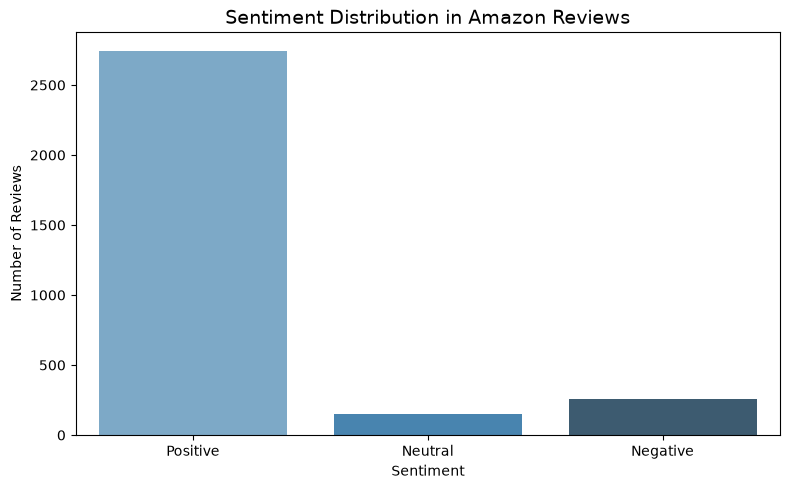

In [11]:
# Plot a bar chart of sentiment distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='sentiment', data=df, palette='Blues_d',
              order=['Positive', 'Neutral', 'Negative'])
plt.title('Sentiment Distribution in Amazon Reviews', fontsize=14)
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

In [12]:
# Add a column showing how many words each review has
df['review_length'] = df['verified_reviews'].dropna().apply(lambda x: len(str(x).split()))

# Show basic statistics about review length
print("Review Length Statistics:")
print(df['review_length'].describe())

Review Length Statistics:
count    3149.000000
mean       25.300730
std        34.587753
min         0.000000
25%         6.000000
50%        14.000000
75%        32.000000
max       526.000000
Name: review_length, dtype: float64


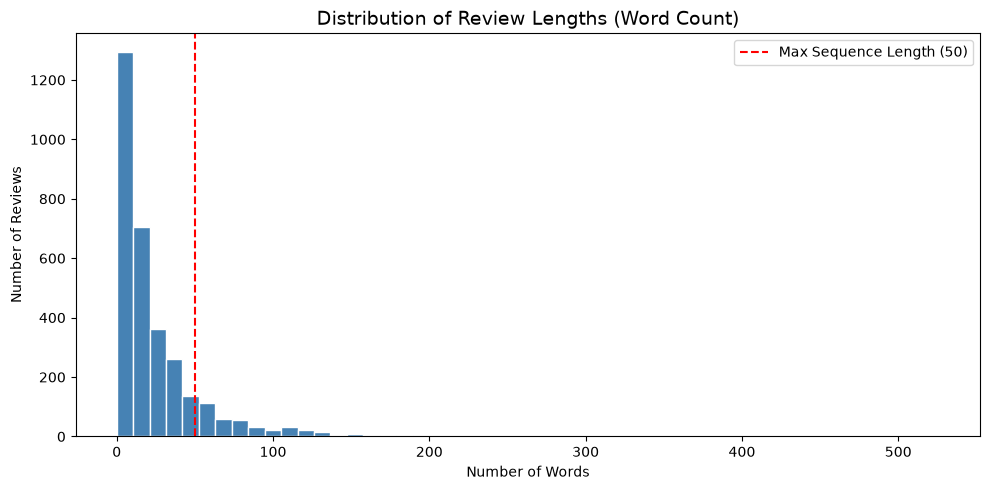

In [13]:
# Plot the distribution of review lengths
plt.figure(figsize=(10, 5))
plt.hist(df['review_length'].dropna(), bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of Review Lengths (Word Count)', fontsize=14)
plt.xlabel('Number of Words')
plt.ylabel('Number of Reviews')
plt.axvline(50, color='red', linestyle='--', label='Max Sequence Length (50)')
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# Remove any rows where the review text is missing
print("Before dropping missing values:", df.shape)
df = df.dropna(subset=['verified_reviews'])
print("After dropping missing values:", df.shape)

Before dropping missing values: (3150, 7)
After dropping missing values: (3149, 7)


In [15]:
# Save the cleaned dataset so we can use it in the next notebook
df[['verified_reviews', 'sentiment']].to_csv('../data/amazon_reviews_cleaned.csv', index=False)
print("Cleaned dataset saved to data/amazon_reviews_cleaned.csv")

Cleaned dataset saved to data/amazon_reviews_cleaned.csv


In [16]:
# Final summary of what we found in the EDA
print("=" * 40)
print("EDA SUMMARY - LensWord")
print("=" * 40)
print(f"Total Reviews:         {df.shape[0]}")
print(f"Positive Reviews:      {(df['sentiment'] == 'Positive').sum()}")
print(f"Neutral Reviews:       {(df['sentiment'] == 'Neutral').sum()}")
print(f"Negative Reviews:      {(df['sentiment'] == 'Negative').sum()}")
print(f"Average Review Length: {df['review_length'].mean():.0f} words")
print("=" * 40)

EDA SUMMARY - LensWord
Total Reviews:         3149
Positive Reviews:      2741
Neutral Reviews:       152
Negative Reviews:      256
Average Review Length: 25 words
